In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn import manifold
from sklearn import tree
from sklearn import metrics

%matplotlib inline

In [2]:
data = pd.read_csv("winequality-red.csv")
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
data["quality"] -= 3

data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,2
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,3
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,3
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,2


In [4]:
train_data = data.head(1000)
test_data = data.tail(599)

train_data
test_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1000,7.5,0.430,0.30,2.20,0.062,6.0,12.0,0.99495,3.44,0.72,11.5,4
1001,9.9,0.350,0.38,1.50,0.058,31.0,47.0,0.99676,3.26,0.82,10.6,4
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,4
1003,6.8,0.360,0.32,1.80,0.067,4.0,8.0,0.99280,3.36,0.55,12.8,4
1004,8.2,0.430,0.29,1.60,0.081,27.0,45.0,0.99603,3.25,0.54,10.3,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.00,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,2
1595,5.9,0.550,0.10,2.20,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,3
1596,6.3,0.510,0.13,2.30,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,3
1597,5.9,0.645,0.12,2.00,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,2


In [8]:
columns = ["fixed acidity",
           "volatile acidity",
           "citric acid",
           "residual sugar",
           "chlorides",
           "free sulfur dioxide",
           "total sulfur dioxide",
           "density",
           "pH",
           "sulphates",
           "alcohol"]

DecisionTreeClassifier(max_depth=12)

In [12]:
train_accuracy = []
test_accuracy = []

for x in range(1, 100):
    decision_tree = tree.DecisionTreeClassifier(max_depth=x)

    decision_tree.fit(train_data[columns], train_data["quality"])
    train_predictions = decision_tree.predict(train_data[columns])
    test_predictions = decision_tree.predict(test_data[columns])

    tr = metrics.accuracy_score(train_data["quality"], train_predictions)
    te = metrics.accuracy_score(test_data["quality"], test_predictions)
    
    train_accuracy.append(tr)
    test_accuracy.append(te)

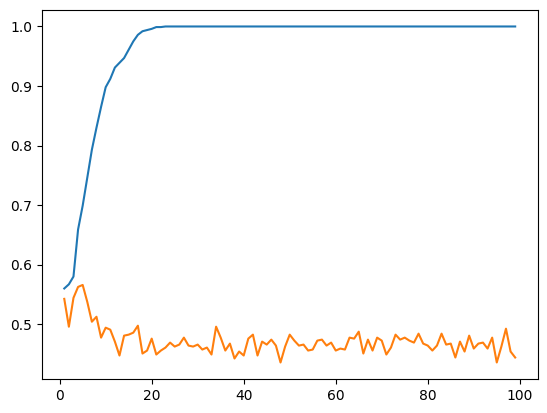

In [14]:
x_values = [i for i in range(1, 100)];

plt.plot(x_values, train_accuracy)
plt.plot(x_values, test_accuracy)
plt.show()